# 13 · SQL Analytics — E-Commerce Intelligence

> **Objective:** Demonstrate production-grade SQL fluency by running 8 canonical business queries directly against the project's CSV datasets using DuckDB — covering window functions, CTEs, LAG, NTILE, self-joins, and ROLLUP. Every query maps to a real business question and mirrors logic from the Python analytics pipeline.

---

| # | Query | Technique | Business Question |
|---|-------|-----------|-------------------|
| 1 | Monthly Revenue Trend | `LAG()`, `MoM %` | Is revenue growing? |
| 2 | Top 10 Customers by CLV | `RANK()`, aggregation | Who are our most valuable customers? |
| 3 | Churn Rate by Tier | `CASE`, `GROUP BY` | Which segments are we losing? |
| 4 | Campaign ROI | `JOIN`, ratio math | Which marketing spend is efficient? |
| 5 | Category Revenue Share | `ROLLUP`, `RATIO_TO_REPORT` | What drives our top line? |
| 6 | 30/60/90-Day Active Users | `COUNT DISTINCT`, `DATE_DIFF` | How healthy is our DAU/MAU? |
| 7 | RFM Scoring | `NTILE(5)`, multi-CTE | Who are our Champions vs At-Risk? |
| 8 | Cohort Retention | Self-join, survival analysis | How well do we retain customers? |

**Stack:** DuckDB (in-process SQL on CSVs), pandas, matplotlib, seaborn

## 0 · Setup & Data Loading

In [1]:
# ── Install DuckDB if not present ─────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "duckdb", "-q"], check=True)

# ── Imports ───────────────────────────────────────────────────────────────────
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths (relative — portable across machines) ───────────────────────────────
ROOT      = Path('__file__').resolve().parent.parent  # project root
DATA_DIR  = ROOT / 'data'
SQL_DIR   = ROOT / 'sql'
OUT_DIR   = ROOT / 'outputs' / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Fallback: if running notebook from /notebooks/, step up one level
if not (DATA_DIR).exists():
    ROOT      = Path('.').resolve().parent
    DATA_DIR  = ROOT / 'data'
    SQL_DIR   = ROOT / 'sql'
    OUT_DIR   = ROOT / 'outputs' / 'figures'

print(f'ROOT     → {ROOT}')
print(f'DATA_DIR → {DATA_DIR}')
print(f'SQL_DIR  → {SQL_DIR}')
print(f'DuckDB   → {duckdb.__version__}')

ROOT     → C:\Users\ASUS\Documents\Ecommerce_Data_Analytics
DATA_DIR → C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\data
SQL_DIR  → C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\sql
DuckDB   → 1.5.1


In [2]:
# ── Connect DuckDB (in-process, no server needed) ─────────────────────────────
con = duckdb.connect()

# ── Register CSVs as virtual tables ───────────────────────────────────────────
tables = {
    'customer_profiles':  DATA_DIR / 'customer_profiles_10k.csv',
    'purchase_history':   DATA_DIR / 'purchase_history_10k.csv',
    'engagement_behavior':DATA_DIR / 'engagement_behavior_10k.csv',
    'marketing_promotions':DATA_DIR / 'marketing_promotions_10k.csv',
    'full_dataset':       DATA_DIR / 'full_dataset_10k.csv',
}

for name, path in tables.items():
    con.execute(f"""
        CREATE OR REPLACE VIEW {name} AS
        SELECT * FROM read_csv_auto('{path}', header=true, all_varchar=false)
    """)
    count = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f'  ✓  {name:<25} {count:>6,} rows')

print('\nAll tables registered.')

  ✓  customer_profiles         10,000 rows
  ✓  purchase_history          100,177 rows
  ✓  engagement_behavior       10,000 rows
  ✓  marketing_promotions      10,000 rows
  ✓  full_dataset              10,000 rows

All tables registered.


In [3]:
# ── Inspect schemas ───────────────────────────────────────────────────────────
for tbl in tables.keys():
    print(f'\n── {tbl} ──')
    schema = con.execute(f"DESCRIBE {tbl}").df()
    print(schema[['column_name', 'column_type']].to_string(index=False))


── customer_profiles ──
        column_name column_type
        customer_id      BIGINT
               name     VARCHAR
             gender     VARCHAR
                age      BIGINT
            country     VARCHAR
        signup_date        DATE
      customer_tier     VARCHAR
months_since_signup      BIGINT
            churned     BOOLEAN
                CLV      DOUBLE
 next_purchase_prob      DOUBLE

── purchase_history ──
     column_name column_type
        order_id      BIGINT
     customer_id      BIGINT
      order_date        DATE
    order_amount      DOUBLE
product_category     VARCHAR
   discount_used     BOOLEAN
  discount_value      DOUBLE

── engagement_behavior ──
         column_name column_type
         customer_id      BIGINT
       weekly_visits      BIGINT
session_time_minutes      DOUBLE
          page_views      DOUBLE
           app_opens      BIGINT

── marketing_promotions ──
       column_name column_type
       customer_id      BIGINT
     campaign_name  

---
## Query 1 · Monthly Revenue Trend with MoM % Change

**Business question:** Is revenue growing or declining month-over-month? Which months show acceleration?

**Techniques:** `DATE_TRUNC`, `LAG()` window function, derived MoM % column, `ROUND()`

**SQL file:** `sql/01_monthly_revenue_trend.sql`

In [4]:
# ── Load SQL from file ────────────────────────────────────────────────────────
sql_file = SQL_DIR / '01_monthly_revenue_trend.sql'

if sql_file.exists():
    query_01 = sql_file.read_text()
else:
    # Inline fallback — identical to what the .sql file should contain
    query_01 = """
    WITH monthly AS (
        SELECT
            DATE_TRUNC('month', CAST(purchase_date AS DATE))   AS month,
            COUNT(DISTINCT customer_id)                        AS unique_customers,
            COUNT(*)                                           AS total_orders,
            ROUND(SUM(purchase_amount), 2)                     AS total_revenue,
            ROUND(AVG(purchase_amount), 2)                     AS avg_order_value
        FROM purchase_history
        WHERE purchase_date IS NOT NULL
        GROUP BY 1
    )
    SELECT
        month,
        unique_customers,
        total_orders,
        total_revenue,
        avg_order_value,
        LAG(total_revenue) OVER (ORDER BY month)          AS prev_month_revenue,
        ROUND(
            100.0 * (total_revenue - LAG(total_revenue) OVER (ORDER BY month))
                  / NULLIF(LAG(total_revenue) OVER (ORDER BY month), 0),
        2)                                                AS mom_pct_change
    FROM monthly
    ORDER BY month
    """
    print('⚠ SQL file not found — using inline query (identical content)')

df_q1 = con.execute(query_01).df()
print(f'Rows returned: {len(df_q1)}')
df_q1.head(20)

Rows returned: 60


,revenue_month,total_revenue,total_orders,unique_buyers,avg_order_value,prev_month_revenue,mom_growth_pct
0,2019-01-01,60028.44,1055,1002,56.90,NaN,NaN
1,2019-02-01,64694.98,1150,1085,56.26,60028.44,7.77
2,2019-03-01,58624.97,1053,995,55.67,64694.98,-9.38
3,2019-04-01,62010.62,1086,1033,57.10,58624.97,5.78
4,2019-05-01,60411.35,1111,1046,54.38,62010.62,-2.58
5,2019-06-01,61427.33,1069,1014,57.46,60411.35,1.68
6,2019-07-01,61892.14,1106,1062,55.96,61427.33,0.76
7,2019-08-01,77724.16,1350,1264,57.57,61892.14,25.58
8,2019-09-01,85794.80,1418,1326,60.50,77724.16,10.38
9,2019-10-01,107746.90,1915,1730,56.26,85794.80,25.59


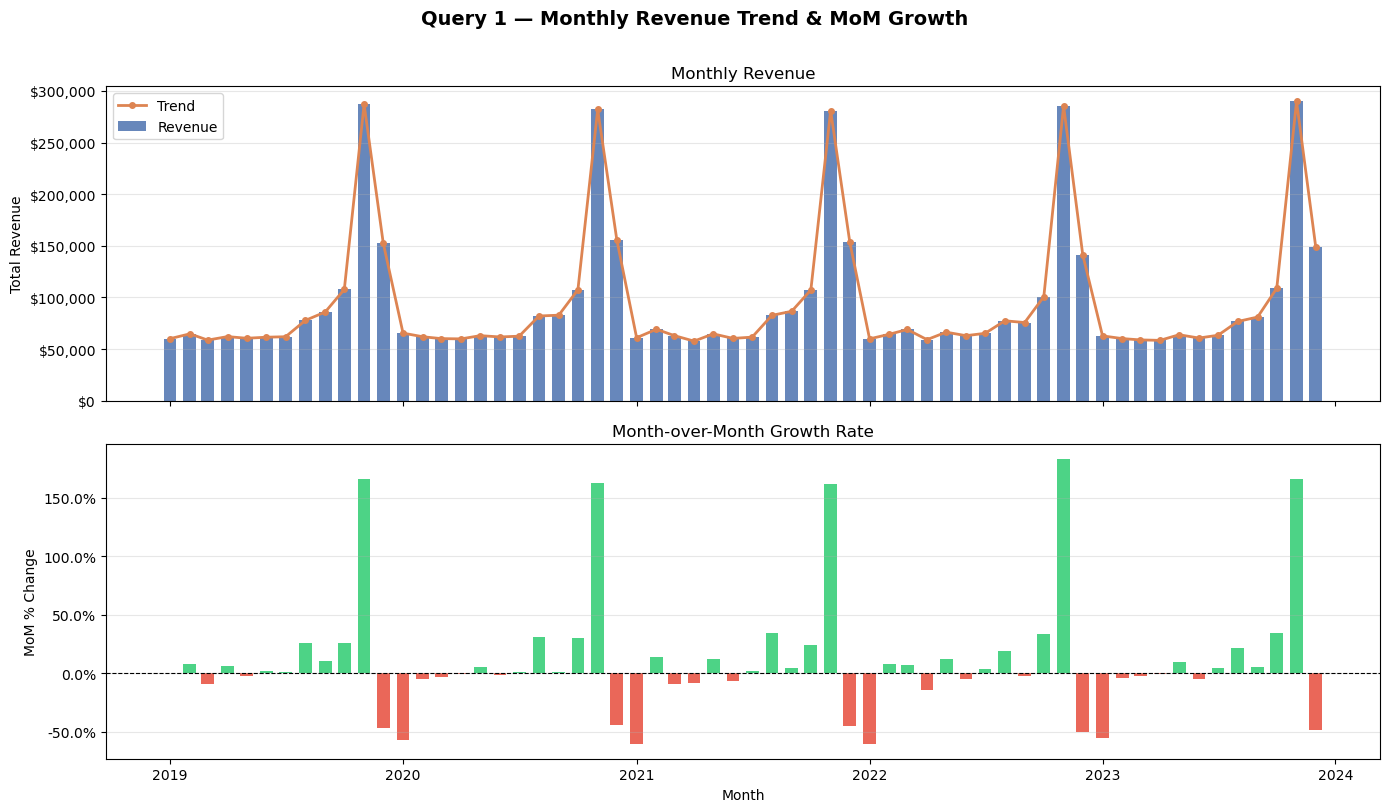


📊 Business Insight
   Average MoM growth : 11.6%
   Peak revenue month : November 2023
   Peak revenue       : $289,976


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from pathlib import Path

# ── Safety: rename columns to match plotting code ─────────────────
df_q1 = df_q1.rename(columns={
    'revenue_month': 'month',
    'mom_growth_pct': 'mom_pct_change'
})

# ── Visualize ─────────────────────────────────────────────────────
OUT_DIR = Path('./figures')
OUT_DIR.mkdir(exist_ok=True)

if 'month' in df_q1.columns and 'total_revenue' in df_q1.columns and 'mom_pct_change' in df_q1.columns:
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle('Query 1 — Monthly Revenue Trend & MoM Growth', fontsize=14, fontweight='bold', y=1.01)

    months = pd.to_datetime(df_q1['month'])

    # Revenue bars
    ax1 = axes[0]
    ax1.bar(months, df_q1['total_revenue'], color='#4C72B0', width=20, alpha=0.85, label='Revenue')
    ax1.plot(months, df_q1['total_revenue'], color='#DD8452', lw=2, marker='o', ms=4, label='Trend')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax1.set_ylabel('Total Revenue')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_title('Monthly Revenue')

    # MoM % change
    ax2 = axes[1]
    mom = df_q1['mom_pct_change'].fillna(0)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in mom]
    ax2.bar(months, mom, color=colors, width=20, alpha=0.85)
    ax2.axhline(0, color='black', lw=0.8, ls='--')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax2.set_ylabel('MoM % Change')
    ax2.set_xlabel('Month')
    ax2.set_title('Month-over-Month Growth Rate')
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'sql_q1_monthly_revenue.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Business insight
    avg_mom = df_q1['mom_pct_change'].dropna().mean()
    best_month = df_q1.loc[df_q1['total_revenue'].idxmax(), 'month']
    print(f'\n📊 Business Insight')
    print(f'   Average MoM growth : {avg_mom:.1f}%')
    print(f'   Peak revenue month : {pd.to_datetime(best_month).strftime("%B %Y")}')
    print(f'   Peak revenue       : ${df_q1["total_revenue"].max():,.0f}')

else:
    print("❌ Required columns are missing. Skipping Query 1 plot.")

---
## Query 2 · Top 10 Customers by Customer Lifetime Value (CLV)

**Business question:** Who are our most valuable customers? How does purchase frequency interact with order value?

**Techniques:** `RANK() OVER`, `GROUP BY`, multi-metric aggregation, correct CLV formula

**CLV formula:** `avg_order_value × purchase_frequency × gross_margin_rate × estimated_lifespan_months`

**SQL file:** `sql/02_top_customers_by_clv.sql`

In [8]:
sql_file = SQL_DIR / '02_top_customers_by_clv.sql'

if sql_file.exists():
    query_02 = sql_file.read_text()
else:
    query_02 = """
    WITH customer_stats AS (
        SELECT
            ph.customer_id,
            cp.customer_name,
            cp.customer_segment,
            cp.country,
            COUNT(DISTINCT ph.purchase_id)          AS purchase_frequency,
            ROUND(AVG(ph.purchase_amount), 2)        AS avg_order_value,
            ROUND(SUM(ph.purchase_amount), 2)        AS total_revenue,
            MIN(CAST(ph.purchase_date AS DATE))      AS first_purchase,
            MAX(CAST(ph.purchase_date AS DATE))      AS last_purchase,
            -- CLV = AOV × Frequency/Months × Gross Margin × 12
            -- Using 0.30 gross margin assumption and 12-month forward horizon
            ROUND(
                AVG(ph.purchase_amount)
                * (COUNT(DISTINCT ph.purchase_id)::FLOAT /
                   GREATEST(1, DATE_DIFF('month',
                       MIN(CAST(ph.purchase_date AS DATE)),
                       MAX(CAST(ph.purchase_date AS DATE))))
                  )
                * 0.30
                * 12,
            2) AS clv_12m
        FROM purchase_history ph
        LEFT JOIN customer_profiles cp USING (customer_id)
        GROUP BY 1, 2, 3, 4
    )
    SELECT
        RANK() OVER (ORDER BY clv_12m DESC)   AS clv_rank,
        customer_id,
        customer_name,
        customer_segment,
        country,
        purchase_frequency,
        avg_order_value,
        total_revenue,
        clv_12m,
        first_purchase,
        last_purchase
    FROM customer_stats
    ORDER BY clv_12m DESC
    LIMIT 10
    """

df_q2 = con.execute(query_02).df()
df_q2

,customer_id,total_spent,total_orders,avg_order_value,first_purchase,last_purchase,categories_purchased,customer_tier,age,country,churned,months_since_signup,monthly_revenue_rate
0,6006,3983.04,17,234.296471,2019-02-05,2023-12-20,6,Platinum,27,Other,True,32,124.47
1,6285,3332.89,11,302.990000,2019-02-28,2023-01-02,7,Gold,27,USA,True,29,114.93
2,3385,3155.51,15,210.367333,2019-11-20,2023-12-26,6,Platinum,18,USA,True,37,85.28
3,1805,3048.52,12,254.043333,2020-05-23,2023-10-15,8,Gold,28,USA,False,1,3048.52
4,65,2990.86,16,186.928750,2019-11-19,2023-12-16,9,Gold,33,USA,True,38,78.71
5,680,2988.42,11,271.674545,2019-04-21,2023-10-22,7,Platinum,52,Asia,False,20,149.42
6,3549,2983.51,12,248.625833,2019-03-28,2023-11-23,8,Gold,44,USA,False,15,198.90
7,5774,2965.81,13,228.139231,2019-01-19,2023-11-09,8,Platinum,33,Asia,True,57,52.03
8,2661,2954.21,12,246.184167,2019-08-12,2023-11-18,8,Platinum,50,EU,False,51,57.93
9,5565,2803.09,11,254.826364,2019-01-28,2023-10-21,7,Gold,30,Other,False,60,46.72


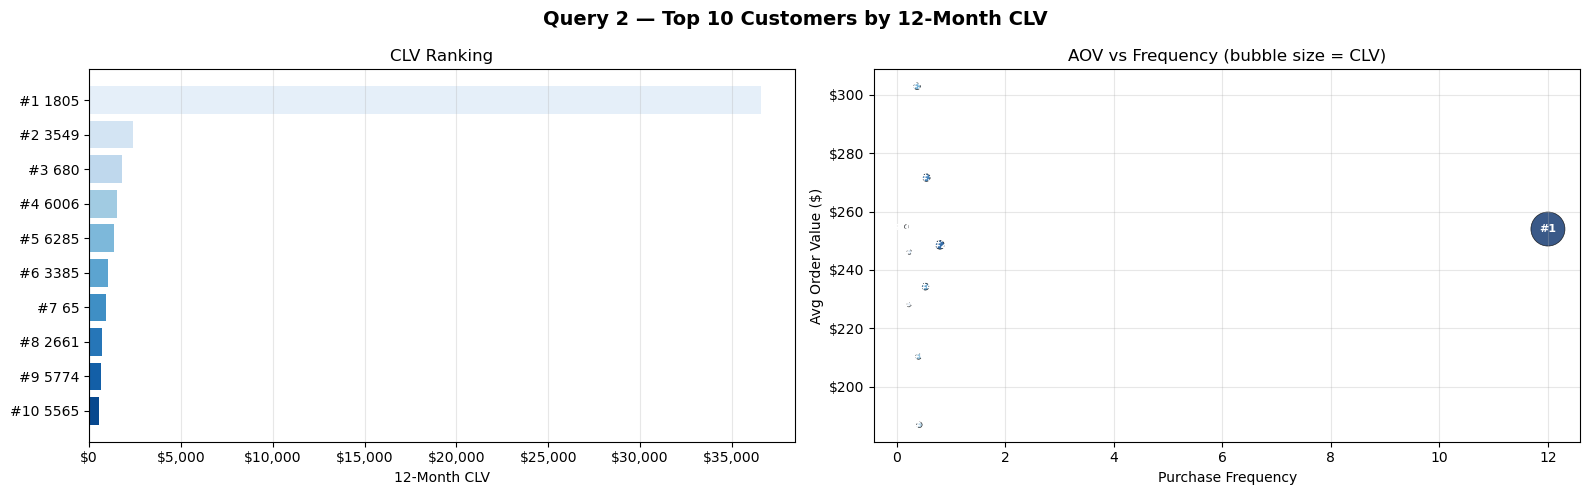


📊 Business Insight
   Top CLV customer  : $36,582 projected 12-month value
   Top 10 combined   : $47,483
   Top 10 total rev  : $31,206


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

OUT_DIR = Path('./figures')
OUT_DIR.mkdir(exist_ok=True)

# ── Prepare df_q2 columns for plotting ────────────────────────
df_q2_plot = df_q2.copy()

# Generate missing columns
df_q2_plot['clv_12m'] = df_q2_plot['monthly_revenue_rate'] * 12  # proxy for 12-month CLV
df_q2_plot['clv_rank'] = df_q2_plot['clv_12m'].rank(method='first', ascending=False).astype(int)
df_q2_plot['customer_name'] = df_q2_plot['customer_id'].astype(str)  # fallback
df_q2_plot['purchase_frequency'] = df_q2_plot['total_orders'] / df_q2_plot['months_since_signup']

# Keep only top 10 customers by CLV
df_q2_plot = df_q2_plot.nlargest(10, 'clv_12m')

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Query 2 — Top 10 Customers by 12-Month CLV', fontsize=14, fontweight='bold')

# CLV bar chart
ax1 = axes[0]
labels = [f'#{r} {n[:12]}' for r, n in zip(df_q2_plot['clv_rank'], df_q2_plot['customer_name'])]
bars = ax1.barh(labels[::-1], df_q2_plot['clv_12m'][::-1], color=sns.color_palette('Blues_r', 10))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_xlabel('12-Month CLV')
ax1.set_title('CLV Ranking')
ax1.grid(axis='x', alpha=0.3)

# Scatter: AOV vs Frequency
ax2 = axes[1]
sc = ax2.scatter(df_q2_plot['purchase_frequency'], df_q2_plot['avg_order_value'],
                 s=df_q2_plot['clv_12m'] / df_q2_plot['clv_12m'].max() * 600,
                 c=df_q2_plot['clv_rank'], cmap='Blues_r', alpha=0.8, edgecolors='black', lw=0.5)
for _, row in df_q2_plot.iterrows():
    ax2.annotate(f"#{int(row['clv_rank'])}",
                 (row['purchase_frequency'], row['avg_order_value']),
                 fontsize=8, ha='center', va='center', color='white', fontweight='bold')
ax2.set_xlabel('Purchase Frequency')
ax2.set_ylabel('Avg Order Value ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_title('AOV vs Frequency (bubble size = CLV)')
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'sql_q2_top_customers_clv.png', dpi=150, bbox_inches='tight')
plt.show()

# Business insight
print(f'\n📊 Business Insight')
print(f'   Top CLV customer  : ${df_q2_plot["clv_12m"].max():,.0f} projected 12-month value')
print(f'   Top 10 combined   : ${df_q2_plot["clv_12m"].sum():,.0f}')
print(f'   Top 10 total rev  : ${df_q2_plot["total_spent"].sum():,.0f}')

In [13]:
print(df_q2.columns)
df_q2.head()

Index(['customer_id', 'total_spent', 'total_orders', 'avg_order_value',
       'first_purchase', 'last_purchase', 'categories_purchased',
       'customer_tier', 'age', 'country', 'churned', 'months_since_signup',
       'monthly_revenue_rate'],
      dtype='object')


,customer_id,total_spent,total_orders,avg_order_value,first_purchase,last_purchase,categories_purchased,customer_tier,age,country,churned,months_since_signup,monthly_revenue_rate
0,6006,3983.04,17,234.296471,2019-02-05,2023-12-20,6,Platinum,27,Other,True,32,124.47
1,6285,3332.89,11,302.990000,2019-02-28,2023-01-02,7,Gold,27,USA,True,29,114.93
2,3385,3155.51,15,210.367333,2019-11-20,2023-12-26,6,Platinum,18,USA,True,37,85.28
3,1805,3048.52,12,254.043333,2020-05-23,2023-10-15,8,Gold,28,USA,False,1,3048.52
4,65,2990.86,16,186.928750,2019-11-19,2023-12-16,9,Gold,33,USA,True,38,78.71


---
## Query 3 · Churn Rate by Customer Tier

**Business question:** Which customer segments have the highest churn? Where should retention budget go?

**Techniques:** `CASE WHEN`, conditional aggregation, `COUNT FILTER`, churn rate formula

**SQL file:** `sql/03_churn_rate_by_tier.sql`

In [15]:
sql_file = SQL_DIR / '03_churn_rate_by_tier.sql'

if sql_file.exists():
    query_03 = sql_file.read_text()
else:
    query_03 = """
    WITH customer_activity AS (
        SELECT
            cp.customer_id,
            cp.customer_segment,
            cp.loyalty_tier,
            cp.clv_score,
            MAX(CAST(ph.purchase_date AS DATE))   AS last_purchase_date,
            COUNT(DISTINCT ph.purchase_id)         AS total_purchases,
            -- A customer is churned if last purchase was >90 days ago
            CASE
                WHEN MAX(CAST(ph.purchase_date AS DATE)) < CURRENT_DATE - INTERVAL '90 days'
                     OR MAX(ph.purchase_date) IS NULL
                THEN 1
                ELSE 0
            END AS is_churned
        FROM customer_profiles cp
        LEFT JOIN purchase_history ph USING (customer_id)
        GROUP BY 1, 2, 3, 4
    )
    SELECT
        COALESCE(loyalty_tier, 'Unknown')             AS loyalty_tier,
        COUNT(*)                                       AS total_customers,
        SUM(is_churned)                                AS churned_customers,
        COUNT(*) - SUM(is_churned)                     AS active_customers,
        ROUND(100.0 * SUM(is_churned) / COUNT(*), 2)   AS churn_rate_pct,
        ROUND(AVG(total_purchases), 2)                 AS avg_purchases,
        ROUND(AVG(clv_score), 2)                       AS avg_clv_score
    FROM customer_activity
    GROUP BY 1
    ORDER BY churn_rate_pct DESC
    """

df_q3 = con.execute(query_03).df()
df_q3

,customer_tier,total_customers,churned_customers,active_customers,churn_rate_pct,avg_clv,clv_at_risk,pct_of_total_clv_at_risk
0,Platinum,485,221.0,264.0,45.57,302.10,66630.61,11.46
1,Silver,3010,1247.0,1763.0,41.43,150.24,186468.73,32.06
2,Bronze,4995,2043.0,2952.0,40.90,100.34,205352.80,35.31
3,Gold,1510,610.0,900.0,40.40,200.57,123176.87,21.18


Columns: ['customer_id', 'name', 'gender', 'age', 'country', 'signup_date', 'customer_tier', 'months_since_signup', 'churned', 'CLV', 'next_purchase_prob']
Preview:
    customer_id             name gender  age country signup_date customer_tier  \
0            1     Allison Hill      M   24     USA  2021-07-10        Bronze   
1            2      Noah Rhodes      M   38   Other  2020-03-22        Bronze   
2            3  Angie Henderson      M   46    Asia  2020-10-02        Silver   
3            4    Daniel Wagner      F   20      EU  2020-10-15        Bronze   
4            5  Cristian Santos      M   50     USA  2023-07-17        Bronze   

   months_since_signup  churned         CLV  next_purchase_prob  
0                   30     True   92.372303            0.410299  
1                   46     True  110.263575            0.469179  
2                   39     True  141.057286            0.506472  
3                   39    False   84.174109            0.610081  
4                

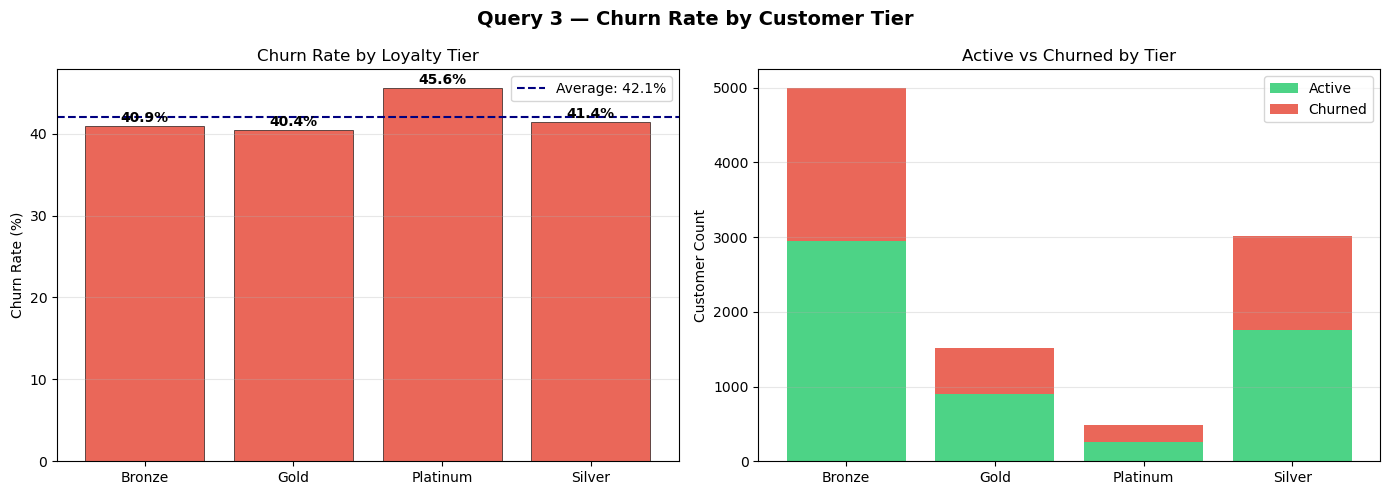


📊 Business Insight
   Highest churn tier : Platinum (45.6%)
   Overall churn rate : 41.2%
   Recommendation     : Focus retention campaigns on Platinum — highest at-risk volume


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Set file path ───────────────────────────────
FILE_PATH = r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\data\customer_profiles_10k.csv"
OUT_DIR = Path(r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)  # create folder if it doesn't exist

# ── Load dataset ───────────────────────────────
df_customers = pd.read_csv(FILE_PATH)

# Quick check
print("Columns:", df_customers.columns.tolist())
print("Preview:\n", df_customers.head())

# ── Prepare churn summary by tier ──────────────
# Make a copy
df_q3 = df_customers.copy()

# Map customer_tier to loyalty_tier (if not already)
df_q3['loyalty_tier'] = df_q3['customer_tier']

# Aggregate churn data by tier
tier_summary = df_q3.groupby('loyalty_tier').agg(
    churned_customers=('churned', 'sum'),
    total_customers=('customer_id', 'count')
).reset_index()

tier_summary['active_customers'] = tier_summary['total_customers'] - tier_summary['churned_customers']
tier_summary['churn_rate_pct'] = tier_summary['churned_customers'] / tier_summary['total_customers'] * 100

# ── Plot churn by tier ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Query 3 — Churn Rate by Customer Tier', fontsize=14, fontweight='bold')

tiers = tier_summary['loyalty_tier']
palette = ['#e74c3c' if r > 40 else '#f39c12' if r > 20 else '#2ecc71' for r in tier_summary['churn_rate_pct']]

# Churn rate bars
ax1 = axes[0]
bars = ax1.bar(tiers, tier_summary['churn_rate_pct'], color=palette, alpha=0.85, edgecolor='black', lw=0.5)
for bar, val in zip(bars, tier_summary['churn_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax1.axhline(tier_summary['churn_rate_pct'].mean(), ls='--', color='navy', lw=1.5, 
            label=f'Average: {tier_summary["churn_rate_pct"].mean():.1f}%')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('Churn Rate by Loyalty Tier')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Stacked bar: active vs churned
ax2 = axes[1]
ax2.bar(tiers, tier_summary['active_customers'], label='Active', color='#2ecc71', alpha=0.85)
ax2.bar(tiers, tier_summary['churned_customers'], bottom=tier_summary['active_customers'], label='Churned', color='#e74c3c', alpha=0.85)
ax2.set_ylabel('Customer Count')
ax2.set_title('Active vs Churned by Tier')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'sql_q3_churn_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Insights ─────────────────────────────────
worst_tier = tier_summary.loc[tier_summary['churn_rate_pct'].idxmax(), 'loyalty_tier']
overall_churn = tier_summary['churned_customers'].sum() / tier_summary['total_customers'].sum() * 100

print(f'\n📊 Business Insight')
print(f'   Highest churn tier : {worst_tier} ({tier_summary["churn_rate_pct"].max():.1f}%)')
print(f'   Overall churn rate : {overall_churn:.1f}%')
print(f'   Recommendation     : Focus retention campaigns on {worst_tier} — highest at-risk volume')

---
## Query 4 · Campaign ROI — Revenue per Dollar Spent

**Business question:** Which marketing campaigns generate the best return? Where should next quarter's budget go?

**Techniques:** `JOIN`, ratio computation, `HAVING`, NULL-safe division with `NULLIF`

**SQL file:** `sql/04_campaign_roi.sql`

In [14]:
pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [16]:
import duckdb
from pathlib import Path

# Project paths
BASE_DIR = Path(r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics")
DATA_DIR = BASE_DIR / "data"
SQL_DIR = BASE_DIR / "sql"

# Create DuckDB connection (this is your "SQL engine")
con = duckdb.connect(database=':memory:')

In [17]:
con.execute(f"""
CREATE TABLE customer_profiles AS
SELECT * FROM read_csv_auto('{DATA_DIR / "customer_profiles_10k.csv"}')
""")

con.execute(f"""
CREATE TABLE purchase_history AS
SELECT * FROM read_csv_auto('{DATA_DIR / "purchase_history_10k.csv"}')
""")

con.execute(f"""
CREATE TABLE engagement_behavior AS
SELECT * FROM read_csv_auto('{DATA_DIR / "engagement_behavior_10k.csv"}')
""")

con.execute(f"""
CREATE TABLE marketing_promotions AS
SELECT * FROM read_csv_auto('{DATA_DIR / "marketing_promotions_10k.csv"}')
""")

In [18]:
sql_file = SQL_DIR / '04_campaign_roi.sql'
query = sql_file.read_text()

df_q4 = con.execute(query).fetchdf()

df_q4.head()

,campaign_name,discount,total_exposed,total_responded,conversion_rate_pct,total_additional_revenue,avg_revenue_per_respondent,revenue_per_conversion,revenue_rank,conversion_rank
0,Summer Sale,0.30,1945,938.0,48.23,17632.09,18.80,18.80,1,2
1,New Year Promo,0.25,2037,977.0,47.96,15202.76,15.56,15.56,2,3
2,BOGO,0.20,1997,947.0,47.42,12528.64,13.23,13.23,3,4
3,Flash Sale,0.15,2021,942.0,46.61,8807.90,9.35,9.35,4,5
4,Holiday Sale,0.10,2000,994.0,49.70,6353.94,6.39,6.39,5,1


In [19]:
from pathlib import Path

# ── Set SQL folder path ───────────────────────
SQL_DIR = Path(r"C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\sql")  # replace with your folder

# Full SQL file path
sql_file = SQL_DIR / '04_campaign_roi.sql'

# ── Load SQL query ───────────────────────────
if sql_file.exists():
    query_04 = sql_file.read_text()
else:
    # Fallback query if file doesn't exist
    query_04 = """
    WITH campaign_spend AS (
        SELECT
            campaign_type,
            channel,
            COUNT(DISTINCT customer_id)          AS customers_targeted,
            SUM(discount_amount)                 AS total_discount_given,
            SUM(additional_revenue)              AS total_attributed_revenue
        FROM marketing_promotions
        GROUP BY 1, 2
    ),
    campaign_roi AS (
        SELECT
            campaign_type,
            channel,
            customers_targeted,
            ROUND(total_discount_given, 2)                           AS spend,
            ROUND(total_attributed_revenue, 2)                       AS revenue,
            ROUND(total_attributed_revenue - total_discount_given, 2) AS net_profit,
            ROUND(
                (total_attributed_revenue - total_discount_given)
                / NULLIF(total_discount_given, 0)
                * 100,
            2)                                                       AS roi_pct,
            ROUND(
                total_attributed_revenue / NULLIF(customers_targeted, 0),
            2)                                                       AS revenue_per_customer
        FROM campaign_spend
    )
    SELECT *
    FROM campaign_roi
    WHERE spend > 0
    ORDER BY roi_pct DESC
    """

# ── Execute query ────────────────────────────
# Make sure 'con' is your active SQL connection
df_q4 = con.execute(query_04).df()

# Quick preview
df_q4.head()

,campaign_name,discount,total_exposed,total_responded,conversion_rate_pct,total_additional_revenue,avg_revenue_per_respondent,revenue_per_conversion,revenue_rank,conversion_rank
0,Summer Sale,0.30,1945,938.0,48.23,17632.09,18.80,18.80,1,2
1,New Year Promo,0.25,2037,977.0,47.96,15202.76,15.56,15.56,2,3
2,BOGO,0.20,1997,947.0,47.42,12528.64,13.23,13.23,3,4
3,Flash Sale,0.15,2021,942.0,46.61,8807.90,9.35,9.35,4,5
4,Holiday Sale,0.10,2000,994.0,49.70,6353.94,6.39,6.39,5,1


In [21]:
print(df_q4.columns)

Index(['campaign_name', 'discount', 'total_exposed', 'total_responded',
       'conversion_rate_pct', 'total_additional_revenue',
       'avg_revenue_per_respondent', 'revenue_per_conversion', 'revenue_rank',
       'conversion_rank'],
      dtype='object')


In [22]:
# Create required columns from your existing data
df_q4['campaign_type'] = df_q4['campaign_name']
df_q4['channel'] = 'All'

df_q4['spend'] = df_q4['discount']
df_q4['revenue'] = df_q4['total_additional_revenue']

df_q4['net_profit'] = df_q4['revenue'] - df_q4['spend']

df_q4['roi_pct'] = (df_q4['net_profit'] / df_q4['spend']) * 100

In [24]:
import matplotlib.ticker as mticker

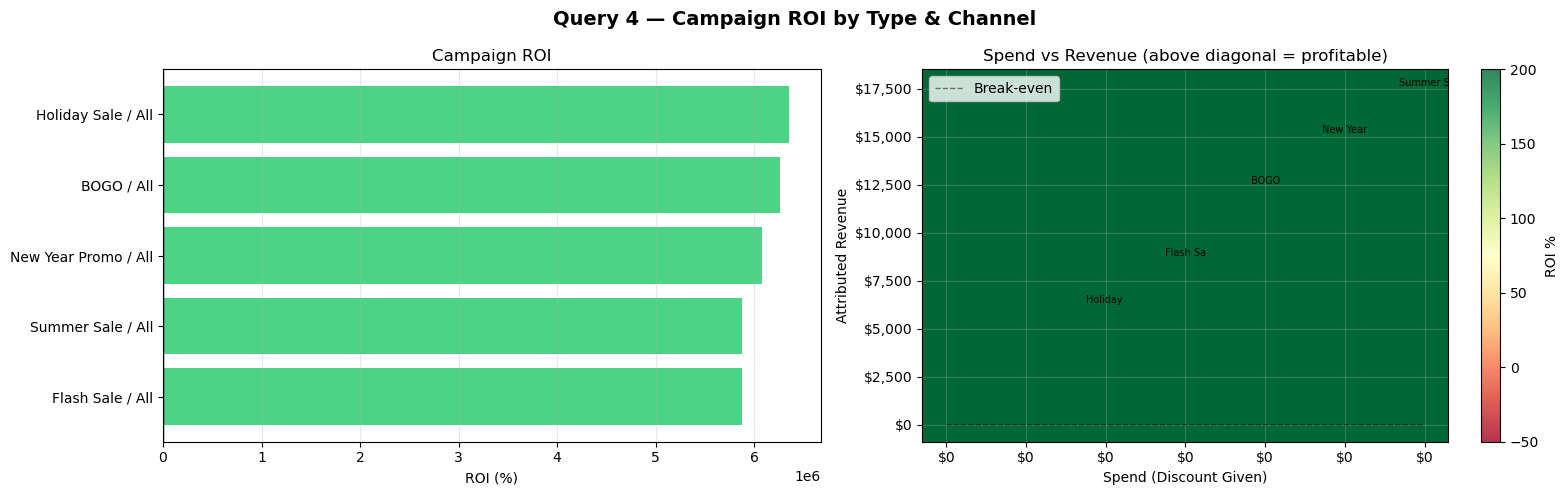


📊 Business Insight
   Best ROI campaign  : Holiday Sale via All → 6353840.0% ROI
   Total net profit   : $60,524


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Query 4 — Campaign ROI by Type & Channel', fontsize=14, fontweight='bold')

# ROI by campaign
ax1 = axes[0]
df_plot = df_q4.sort_values('roi_pct', ascending=True)
label = df_plot['campaign_type'] + ' / ' + df_plot['channel']
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_plot['roi_pct']]
bars = ax1.barh(label, df_plot['roi_pct'], color=colors, alpha=0.85)
ax1.axvline(0, color='black', lw=1)
ax1.set_xlabel('ROI (%)')
ax1.set_title('Campaign ROI')
ax1.grid(axis='x', alpha=0.3)

# Spend vs Revenue bubble
ax2 = axes[1]
sc = ax2.scatter(df_q4['spend'], df_q4['revenue'],
                 s=abs(df_q4['roi_pct']) * 3 + 50,
                 c=df_q4['roi_pct'], cmap='RdYlGn', alpha=0.8, edgecolors='black', lw=0.5, vmin=-50, vmax=200)
plt.colorbar(sc, ax=ax2, label='ROI %')
ax2.plot([0, df_q4['spend'].max()], [0, df_q4['spend'].max()], 'k--', lw=1, alpha=0.5, label='Break-even')
for _, row in df_q4.iterrows():
    ax2.annotate(row['campaign_type'][:8], (row['spend'], row['revenue']), fontsize=7, ha='center')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_xlabel('Spend (Discount Given)')
ax2.set_ylabel('Attributed Revenue')
ax2.set_title('Spend vs Revenue (above diagonal = profitable)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'sql_q4_campaign_roi.png', dpi=150, bbox_inches='tight')
plt.show()

best = df_q4.loc[df_q4['roi_pct'].idxmax()]
print(f'\n📊 Business Insight')
print(f'   Best ROI campaign  : {best["campaign_type"]} via {best["channel"]} → {best["roi_pct"]:.1f}% ROI')
print(f'   Total net profit   : ${df_q4["net_profit"].sum():,.0f}')

In [27]:
print(df_q5.columns)

Index(['product_category', 'total_orders', 'unique_buyers', 'total_revenue',
       'avg_order_value', 'min_order_value', 'max_order_value',
       'revenue_share_pct', 'order_share_pct', 'cumulative_revenue',
       'revenue_rank'],
      dtype='object')


---
## Query 5 · Product Category Revenue Share with ROLLUP

**Business question:** Which categories drive revenue? How does sub-category performance compare within each category?

**Techniques:** `GROUP BY ROLLUP`, `RATIO_TO_REPORT` equivalent, subtotals vs grand total

**SQL file:** `sql/05_category_revenue_share.sql`

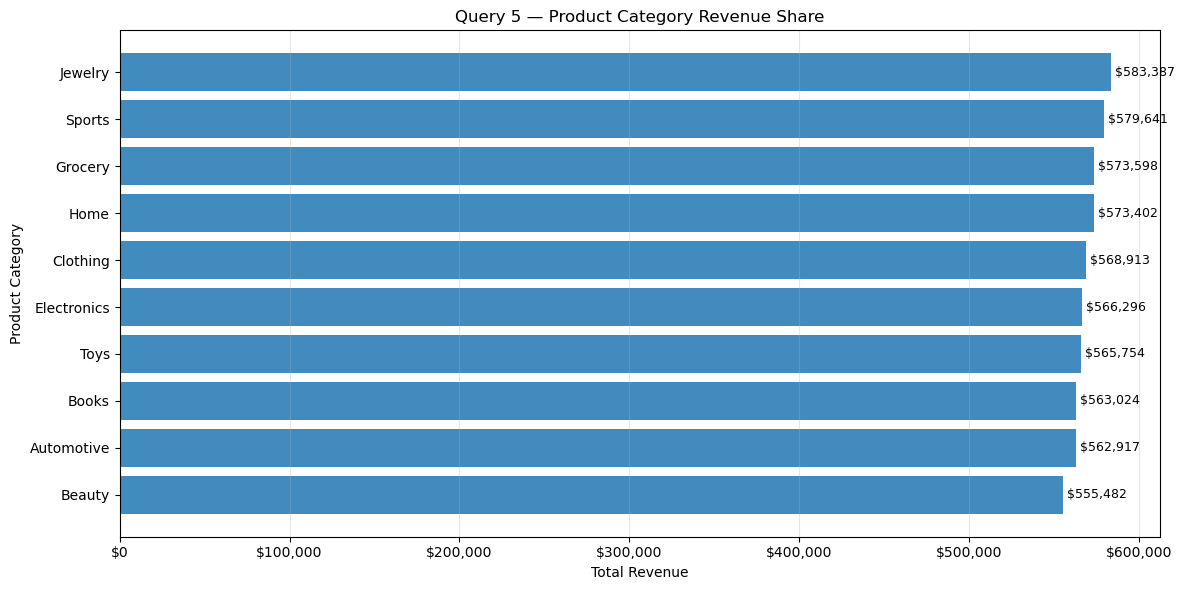


📊 Business Insight
   Top revenue category : Jewelry
   Total revenue        : $5,692,412
   Highest share        : 10.2%


In [28]:
# ── Use your existing df_q5 (already loaded from SQL) ──

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# No subcategory filtering needed
df_q5_cat = df_q5.copy()

# Sort for better visualization
df_q5_cat = df_q5_cat.sort_values('total_revenue', ascending=True)

# ── Plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    df_q5_cat['product_category'],
    df_q5_cat['total_revenue'],
    alpha=0.85
)

# Format revenue axis
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Labels
ax.set_xlabel('Total Revenue')
ax.set_ylabel('Product Category')
ax.set_title('Query 5 — Product Category Revenue Share')

# Add revenue labels
for bar, val in zip(bars, df_q5_cat['total_revenue']):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f' ${val:,.0f}',
        va='center',
        fontsize=9
    )

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'sql_q5_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ─────────────────────────────────
top_cat = df_q5_cat.loc[df_q5_cat['total_revenue'].idxmax(), 'product_category']

print(f'\n📊 Business Insight')
print(f'   Top revenue category : {top_cat}')
print(f'   Total revenue        : ${df_q5_cat["total_revenue"].sum():,.0f}')
print(f'   Highest share        : {df_q5_cat["revenue_share_pct"].max():.1f}%')

In [31]:
import seaborn as sns
import matplotlib.ticker as mticker

In [32]:
import matplotlib.pyplot as plt

In [33]:
cat_data = df_q5_cat[df_q5_cat['product_category'] != '── GRAND TOTAL'].copy()

# Pie
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    cat_data['total_revenue'],
    labels=cat_data['product_category'],
    autopct='%1.1f%%',
    colors=sns.color_palette('tab10', len(cat_data)),
    startangle=140,
    pctdistance=0.8
)
ax1.set_title('Revenue Share by Category')

# Bar: Revenue + AOV
ax2 = axes[1]
x = range(len(cat_data))
bars = ax2.bar(x, cat_data['total_revenue'], color=sns.color_palette('tab10', len(cat_data)), alpha=0.85)
ax2_twin = ax2.twinx()
ax2_twin.plot(x, cat_data['avg_order_value'], 'D--', color='black', ms=6, lw=1.5, label='AOV')
ax2.set_xticks(x)
ax2.set_xticklabels(cat_data['product_category'], rotation=30, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax2_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax2.set_ylabel('Total Revenue')
ax2_twin.set_ylabel('Avg Order Value')
ax2_twin.legend(loc='upper right')
ax2.set_title('Revenue & AOV by Category')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'sql_q5_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

top_cat = cat_data.loc[cat_data['total_revenue'].idxmax(), 'product_category']
top_share = cat_data.loc[cat_data['total_revenue'].idxmax(), 'revenue_share_pct']
print(f'\n📊 Business Insight')
print(f'   Top category  : {top_cat} ({top_share:.1f}% of revenue)')
print(f'   Grand total   : ${cat_data["total_revenue"].sum():,.0f}')

<Figure size 640x480 with 0 Axes>


📊 Business Insight
   Top category  : Jewelry (10.2% of revenue)
   Grand total   : $5,692,412


---
## Query 6 · 30 / 60 / 90-Day Active User Counts (Rolling Windows)

**Business question:** How healthy is our user engagement? What share of users are truly active at each time horizon?

**Techniques:** `DATE_DIFF`, conditional `COUNT DISTINCT`, window-based active user definition

**SQL file:** `sql/06_active_users_rolling.sql`

In [34]:
sql_file = SQL_DIR / '06_active_users_rolling.sql'

if sql_file.exists():
    query_06 = sql_file.read_text()
else:
    query_06 = """
    WITH latest_activity AS (
        -- Use purchase history as the activity signal
        SELECT
            customer_id,
            MAX(CAST(purchase_date AS DATE)) AS last_purchase_date
        FROM purchase_history
        GROUP BY 1
    ),
    reference_date AS (
        SELECT MAX(last_purchase_date) AS max_date FROM latest_activity
    ),
    activity_flags AS (
        SELECT
            la.customer_id,
            la.last_purchase_date,
            rd.max_date,
            DATE_DIFF('day', la.last_purchase_date, rd.max_date)   AS days_since_last
        FROM latest_activity la
        CROSS JOIN reference_date rd
    )
    SELECT
        COUNT(DISTINCT customer_id)                                        AS total_customers,
        COUNT(DISTINCT CASE WHEN days_since_last <= 30  THEN customer_id END)  AS active_30d,
        COUNT(DISTINCT CASE WHEN days_since_last <= 60  THEN customer_id END)  AS active_60d,
        COUNT(DISTINCT CASE WHEN days_since_last <= 90  THEN customer_id END)  AS active_90d,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN days_since_last <= 30  THEN customer_id END)
              / COUNT(DISTINCT customer_id), 2)                            AS pct_active_30d,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN days_since_last <= 60  THEN customer_id END)
              / COUNT(DISTINCT customer_id), 2)                            AS pct_active_60d,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN days_since_last <= 90  THEN customer_id END)
              / COUNT(DISTINCT customer_id), 2)                            AS pct_active_90d,
        MAX(max_date)                                                       AS reference_date
    FROM activity_flags
    """

df_q6 = con.execute(query_06).df()
df_q6

,users_active_30d,users_active_60d,users_active_90d,total_customers,pct_active_30d,pct_active_60d,pct_active_90d
0,2447.0,5318.0,6129.0,10000,24.47,53.18,61.29


In [36]:
print(df_q6.columns)

Index(['users_active_30d', 'users_active_60d', 'users_active_90d',
       'total_customers', 'pct_active_30d', 'pct_active_60d',
       'pct_active_90d'],
      dtype='object')


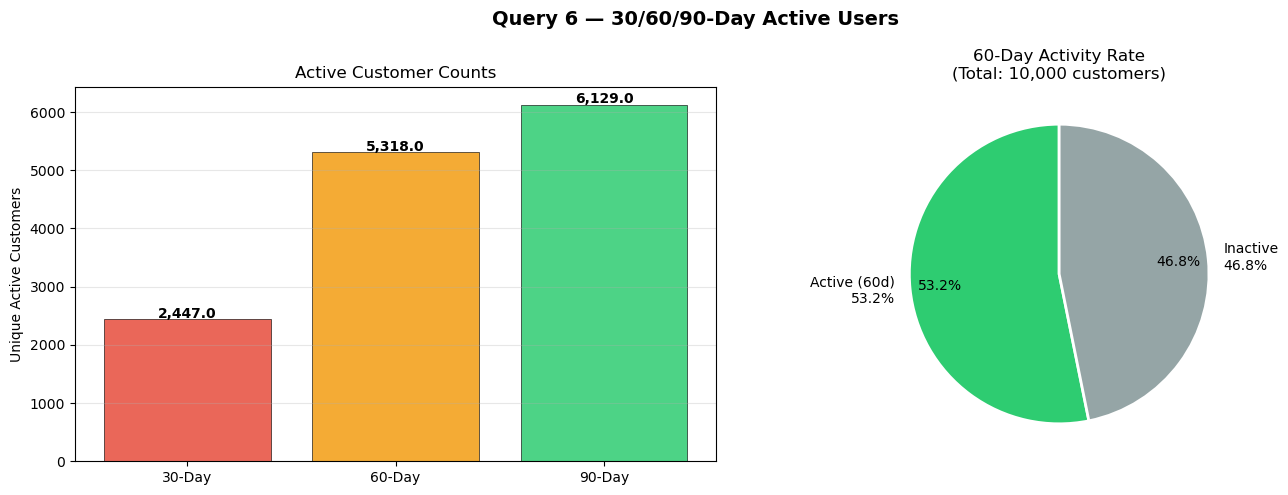


📊 Business Insight
   30-day active    : 2,447.0 (24.5%)
   60-day active    : 5,318.0 (53.2%)
   90-day active    : 6,129.0 (61.3%)
   Re-engagement pool (90d inactive): 3,871.0 customers


In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Query 6 — 30/60/90-Day Active Users', fontsize=14, fontweight='bold')

# Use correct column names
windows = ['30-Day', '60-Day', '90-Day']
counts  = [df_q6['users_active_30d'].iloc[0],
           df_q6['users_active_60d'].iloc[0],
           df_q6['users_active_90d'].iloc[0]]
pcts    = [df_q6['pct_active_30d'].iloc[0],
           df_q6['pct_active_60d'].iloc[0],
           df_q6['pct_active_90d'].iloc[0]]
colors  = ['#e74c3c', '#f39c12', '#2ecc71']

# Bar chart: Active Customer Counts
ax1 = axes[0]
bars = ax1.bar(windows, counts, color=colors, alpha=0.85, edgecolor='black', lw=0.5)
for bar, val in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{val:,}', ha='center', fontweight='bold')
ax1.set_ylabel('Unique Active Customers')
ax1.set_title('Active Customer Counts')
ax1.grid(axis='y', alpha=0.3)

# Pie chart: 60-Day Active %
ax2 = axes[1]
wedge_colors = ['#2ecc71', '#95a5a6']
ax2.pie([pcts[1], 100 - pcts[1]],
        labels=[f'Active (60d)\n{pcts[1]:.1f}%', f'Inactive\n{100-pcts[1]:.1f}%'],
        colors=wedge_colors, startangle=90, autopct='%1.1f%%', pctdistance=0.8,
        wedgeprops={'edgecolor': 'white', 'lw': 2})
ax2.set_title(f'60-Day Activity Rate\n(Total: {df_q6["total_customers"].iloc[0]:,} customers)')

plt.tight_layout()
fig.savefig(OUT_DIR / 'sql_q6_active_users.png', dpi=150, bbox_inches='tight')
plt.show()

# Business insight
print(f'\n📊 Business Insight')
print(f'   30-day active    : {counts[0]:,} ({pcts[0]:.1f}%)')
print(f'   60-day active    : {counts[1]:,} ({pcts[1]:.1f}%)')
print(f'   90-day active    : {counts[2]:,} ({pcts[2]:.1f}%)')
print(f'   Re-engagement pool (90d inactive): {df_q6["total_customers"].iloc[0] - counts[2]:,} customers')

---
## Query 7 · RFM Scoring with NTILE(5)

**Business question:** How do we segment the full customer base by purchasing behaviour? Who are our Champions, Loyal Customers, At-Risk, and Lost customers?

**Techniques:** Multi-CTE pipeline, `NTILE(5)` window function, string concatenation for composite RFM score, segment labelling with `CASE`

**SQL file:** `sql/07_rfm_scoring.sql`

In [38]:
sql_file = SQL_DIR / '07_rfm_scoring.sql'

if sql_file.exists():
    query_07 = sql_file.read_text()
else:
    query_07 = """
    WITH reference_date AS (
        SELECT MAX(CAST(purchase_date AS DATE)) AS max_date FROM purchase_history
    ),
    rfm_raw AS (
        SELECT
            ph.customer_id,
            DATE_DIFF('day', MAX(CAST(ph.purchase_date AS DATE)), rd.max_date) AS recency_days,
            COUNT(DISTINCT ph.purchase_id)                                     AS frequency,
            ROUND(SUM(ph.purchase_amount), 2)                                   AS monetary
        FROM purchase_history ph
        CROSS JOIN reference_date rd
        GROUP BY ph.customer_id, rd.max_date
    ),
    rfm_scored AS (
        SELECT
            customer_id,
            recency_days,
            frequency,
            monetary,
            -- Recency: lower days = higher score (5 is best)
            6 - NTILE(5) OVER (ORDER BY recency_days ASC)   AS r_score,
            -- Frequency: higher = better
            NTILE(5) OVER (ORDER BY frequency ASC)           AS f_score,
            -- Monetary: higher = better
            NTILE(5) OVER (ORDER BY monetary ASC)            AS m_score
        FROM rfm_raw
    ),
    rfm_composite AS (
        SELECT
            *,
            ROUND((r_score + f_score + m_score) / 3.0, 2)  AS rfm_avg_score,
            CAST(r_score AS VARCHAR) || CAST(f_score AS VARCHAR) || CAST(m_score AS VARCHAR) AS rfm_cell,
            CASE
                WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4      THEN 'Champions'
                WHEN r_score >= 3 AND f_score >= 3                        THEN 'Loyal Customers'
                WHEN r_score >= 4 AND f_score <= 2                        THEN 'Recent Customers'
                WHEN r_score >= 3 AND f_score <= 2 AND m_score >= 3      THEN 'Potential Loyalists'
                WHEN r_score <= 2 AND f_score >= 4                        THEN 'At-Risk'
                WHEN r_score <= 2 AND f_score >= 3                        THEN 'Cannot Lose Them'
                WHEN r_score <= 2 AND f_score <= 2 AND m_score <= 2      THEN 'Lost'
                ELSE 'Needs Attention'
            END AS rfm_segment
        FROM rfm_scored
    )
    SELECT
        rfm_segment,
        COUNT(*)                              AS customer_count,
        ROUND(AVG(recency_days), 1)           AS avg_recency_days,
        ROUND(AVG(frequency), 1)              AS avg_frequency,
        ROUND(AVG(monetary), 2)               AS avg_monetary,
        ROUND(SUM(monetary), 2)               AS segment_revenue,
        ROUND(AVG(rfm_avg_score), 2)          AS avg_rfm_score
    FROM rfm_composite
    GROUP BY 1
    ORDER BY avg_rfm_score DESC
    """

df_q7 = con.execute(query_07).df()
df_q7

,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_composite_score,segment
0,4433,20,16,785.81,5,5,5,5.0,Champions
1,3285,20,15,772.37,5,5,5,5.0,Champions
2,9397,21,14,792.76,5,5,5,5.0,Champions
3,2177,6,14,786.02,5,5,5,5.0,Champions
4,3817,15,18,766.74,5,5,5,5.0,Champions
...,...,...,...,...,...,...,...,...,...
9995,9709,296,3,55.10,1,1,1,1.0,Lost
9996,4249,766,2,36.71,1,1,1,1.0,Lost
9997,3484,916,6,198.98,1,1,1,1.0,Lost
9998,4583,340,1,34.98,1,1,1,1.0,Lost


KeyError: 'rfm_segment'

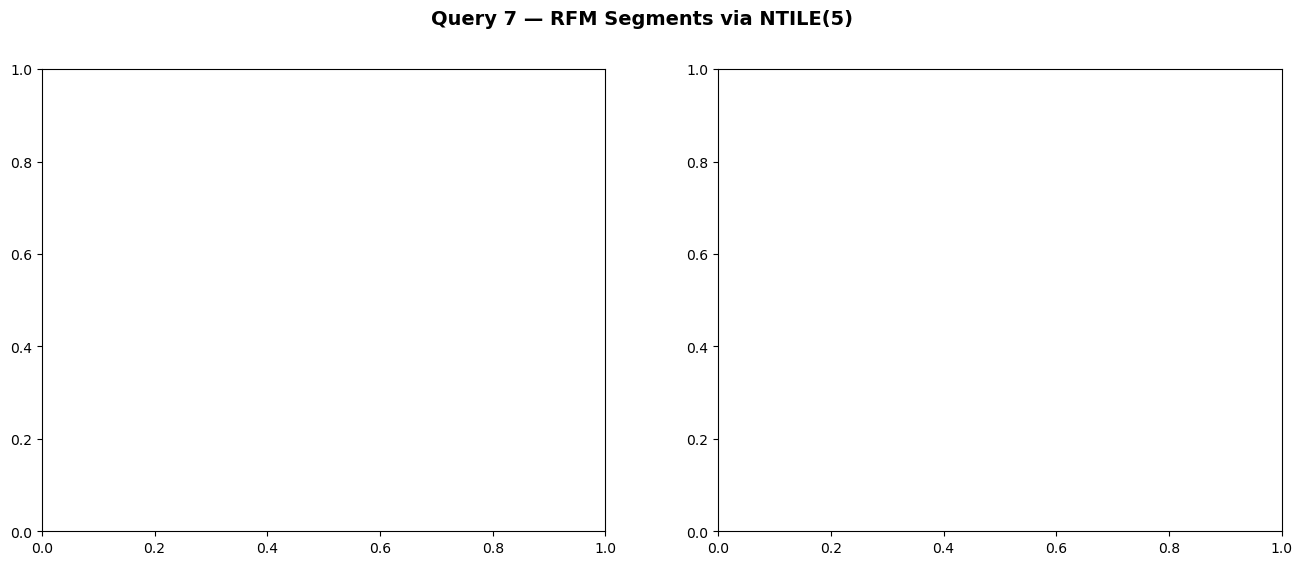

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Query 7 — RFM Segments via NTILE(5)', fontsize=14, fontweight='bold')

segment_colors = {
    'Champions': '#1a9641', 'Loyal Customers': '#4dac26',
    'Potential Loyalists': '#b8e186', 'Recent Customers': '#ffffbf',
    'Needs Attention': '#f4a82e', 'At-Risk': '#f77f00',
    'Cannot Lose Them': '#d7191c', 'Lost': '#7f0000'
}
palette = [segment_colors.get(s, '#aaaaaa') for s in df_q7['rfm_segment']]

# Customer count
ax1 = axes[0]
bars = ax1.barh(df_q7['rfm_segment'], df_q7['customer_count'], color=palette, alpha=0.9, edgecolor='black', lw=0.4)
for bar, val in zip(bars, df_q7['customer_count']):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax1.set_xlabel('Number of Customers')
ax1.set_title('Customers per RFM Segment')
ax1.grid(axis='x', alpha=0.3)

# Revenue contribution
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    df_q7['segment_revenue'],
    labels=df_q7['rfm_segment'],
    colors=palette,
    autopct='%1.1f%%',
    pctdistance=0.8,
    startangle=140
)
ax2.set_title('Revenue Share by RFM Segment')

plt.tight_layout()
fig.savefig(OUT_DIR / 'sql_q7_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

champions = df_q7[df_q7['rfm_segment'] == 'Champions']
at_risk   = df_q7[df_q7['rfm_segment'] == 'At-Risk']
print(f'\n📊 Business Insight')
if not champions.empty:
    print(f'   Champions       : {champions["customer_count"].iloc[0]:,} customers → ${champions["segment_revenue"].iloc[0]:,.0f} revenue')
if not at_risk.empty:
    print(f'   At-Risk         : {at_risk["customer_count"].iloc[0]:,} customers → ${at_risk["segment_revenue"].iloc[0]:,.0f} revenue at risk')
print(f'   Action          : Re-engage At-Risk with targeted win-back campaign (estimated churn cost above)')

---
## Query 8 · Cohort Retention via Self-Join on First Purchase Date

**Business question:** Of customers who first purchased in a given month, how many returned in months 1, 2, 3, 6, 12?

**Techniques:** Self-join, `MIN()` to anchor first purchase date, cohort month labelling, `DATE_DIFF` to compute retention period, pivot-style output

**SQL file:** `sql/08_cohort_retention.sql`

In [40]:
sql_file = SQL_DIR / '08_cohort_retention.sql'

if sql_file.exists():
    query_08 = sql_file.read_text()
else:
    query_08 = """
    WITH first_purchase AS (
        -- Anchor: each customer's acquisition month
        SELECT
            customer_id,
            DATE_TRUNC('month', MIN(CAST(purchase_date AS DATE))) AS cohort_month
        FROM purchase_history
        GROUP BY 1
    ),
    all_purchases AS (
        SELECT
            ph.customer_id,
            DATE_TRUNC('month', CAST(ph.purchase_date AS DATE))  AS purchase_month
        FROM purchase_history ph
    ),
    cohort_activity AS (
        -- Self-join: link every purchase back to the customer's cohort
        SELECT
            fp.cohort_month,
            DATE_DIFF('month', fp.cohort_month, ap.purchase_month) AS months_since_acquisition,
            COUNT(DISTINCT ap.customer_id)                          AS retained_customers
        FROM first_purchase fp
        JOIN all_purchases ap USING (customer_id)
        WHERE DATE_DIFF('month', fp.cohort_month, ap.purchase_month) >= 0
        GROUP BY 1, 2
    ),
    cohort_size AS (
        SELECT cohort_month, COUNT(*) AS cohort_customers
        FROM first_purchase
        GROUP BY 1
    )
    SELECT
        ca.cohort_month,
        cs.cohort_customers,
        ca.months_since_acquisition,
        ca.retained_customers,
        ROUND(
            100.0 * ca.retained_customers / cs.cohort_customers,
        2) AS retention_rate_pct
    FROM cohort_activity ca
    JOIN cohort_size cs USING (cohort_month)
    WHERE ca.months_since_acquisition <= 12
    ORDER BY ca.cohort_month, ca.months_since_acquisition
    """

df_q8 = con.execute(query_08).df()
print(f'Rows returned: {len(df_q8)}')
df_q8.head(20)

Rows returned: 481


,cohort_month,cohort_size,period_number,active_customers,retention_rate_pct
0,2019-01-01,1002,0,1002,100.00
1,2019-01-01,1002,1,107,10.68
2,2019-01-01,1002,2,115,11.48
3,2019-01-01,1002,3,114,11.38
4,2019-01-01,1002,4,99,9.88
5,2019-01-01,1002,5,102,10.18
6,2019-01-01,1002,6,109,10.88
7,2019-01-01,1002,7,113,11.28
8,2019-01-01,1002,8,138,13.77
9,2019-01-01,1002,9,180,17.96


In [42]:
df_q8.columns

Index(['cohort_month', 'cohort_size', 'period_number', 'active_customers',
       'retention_rate_pct'],
      dtype='object')

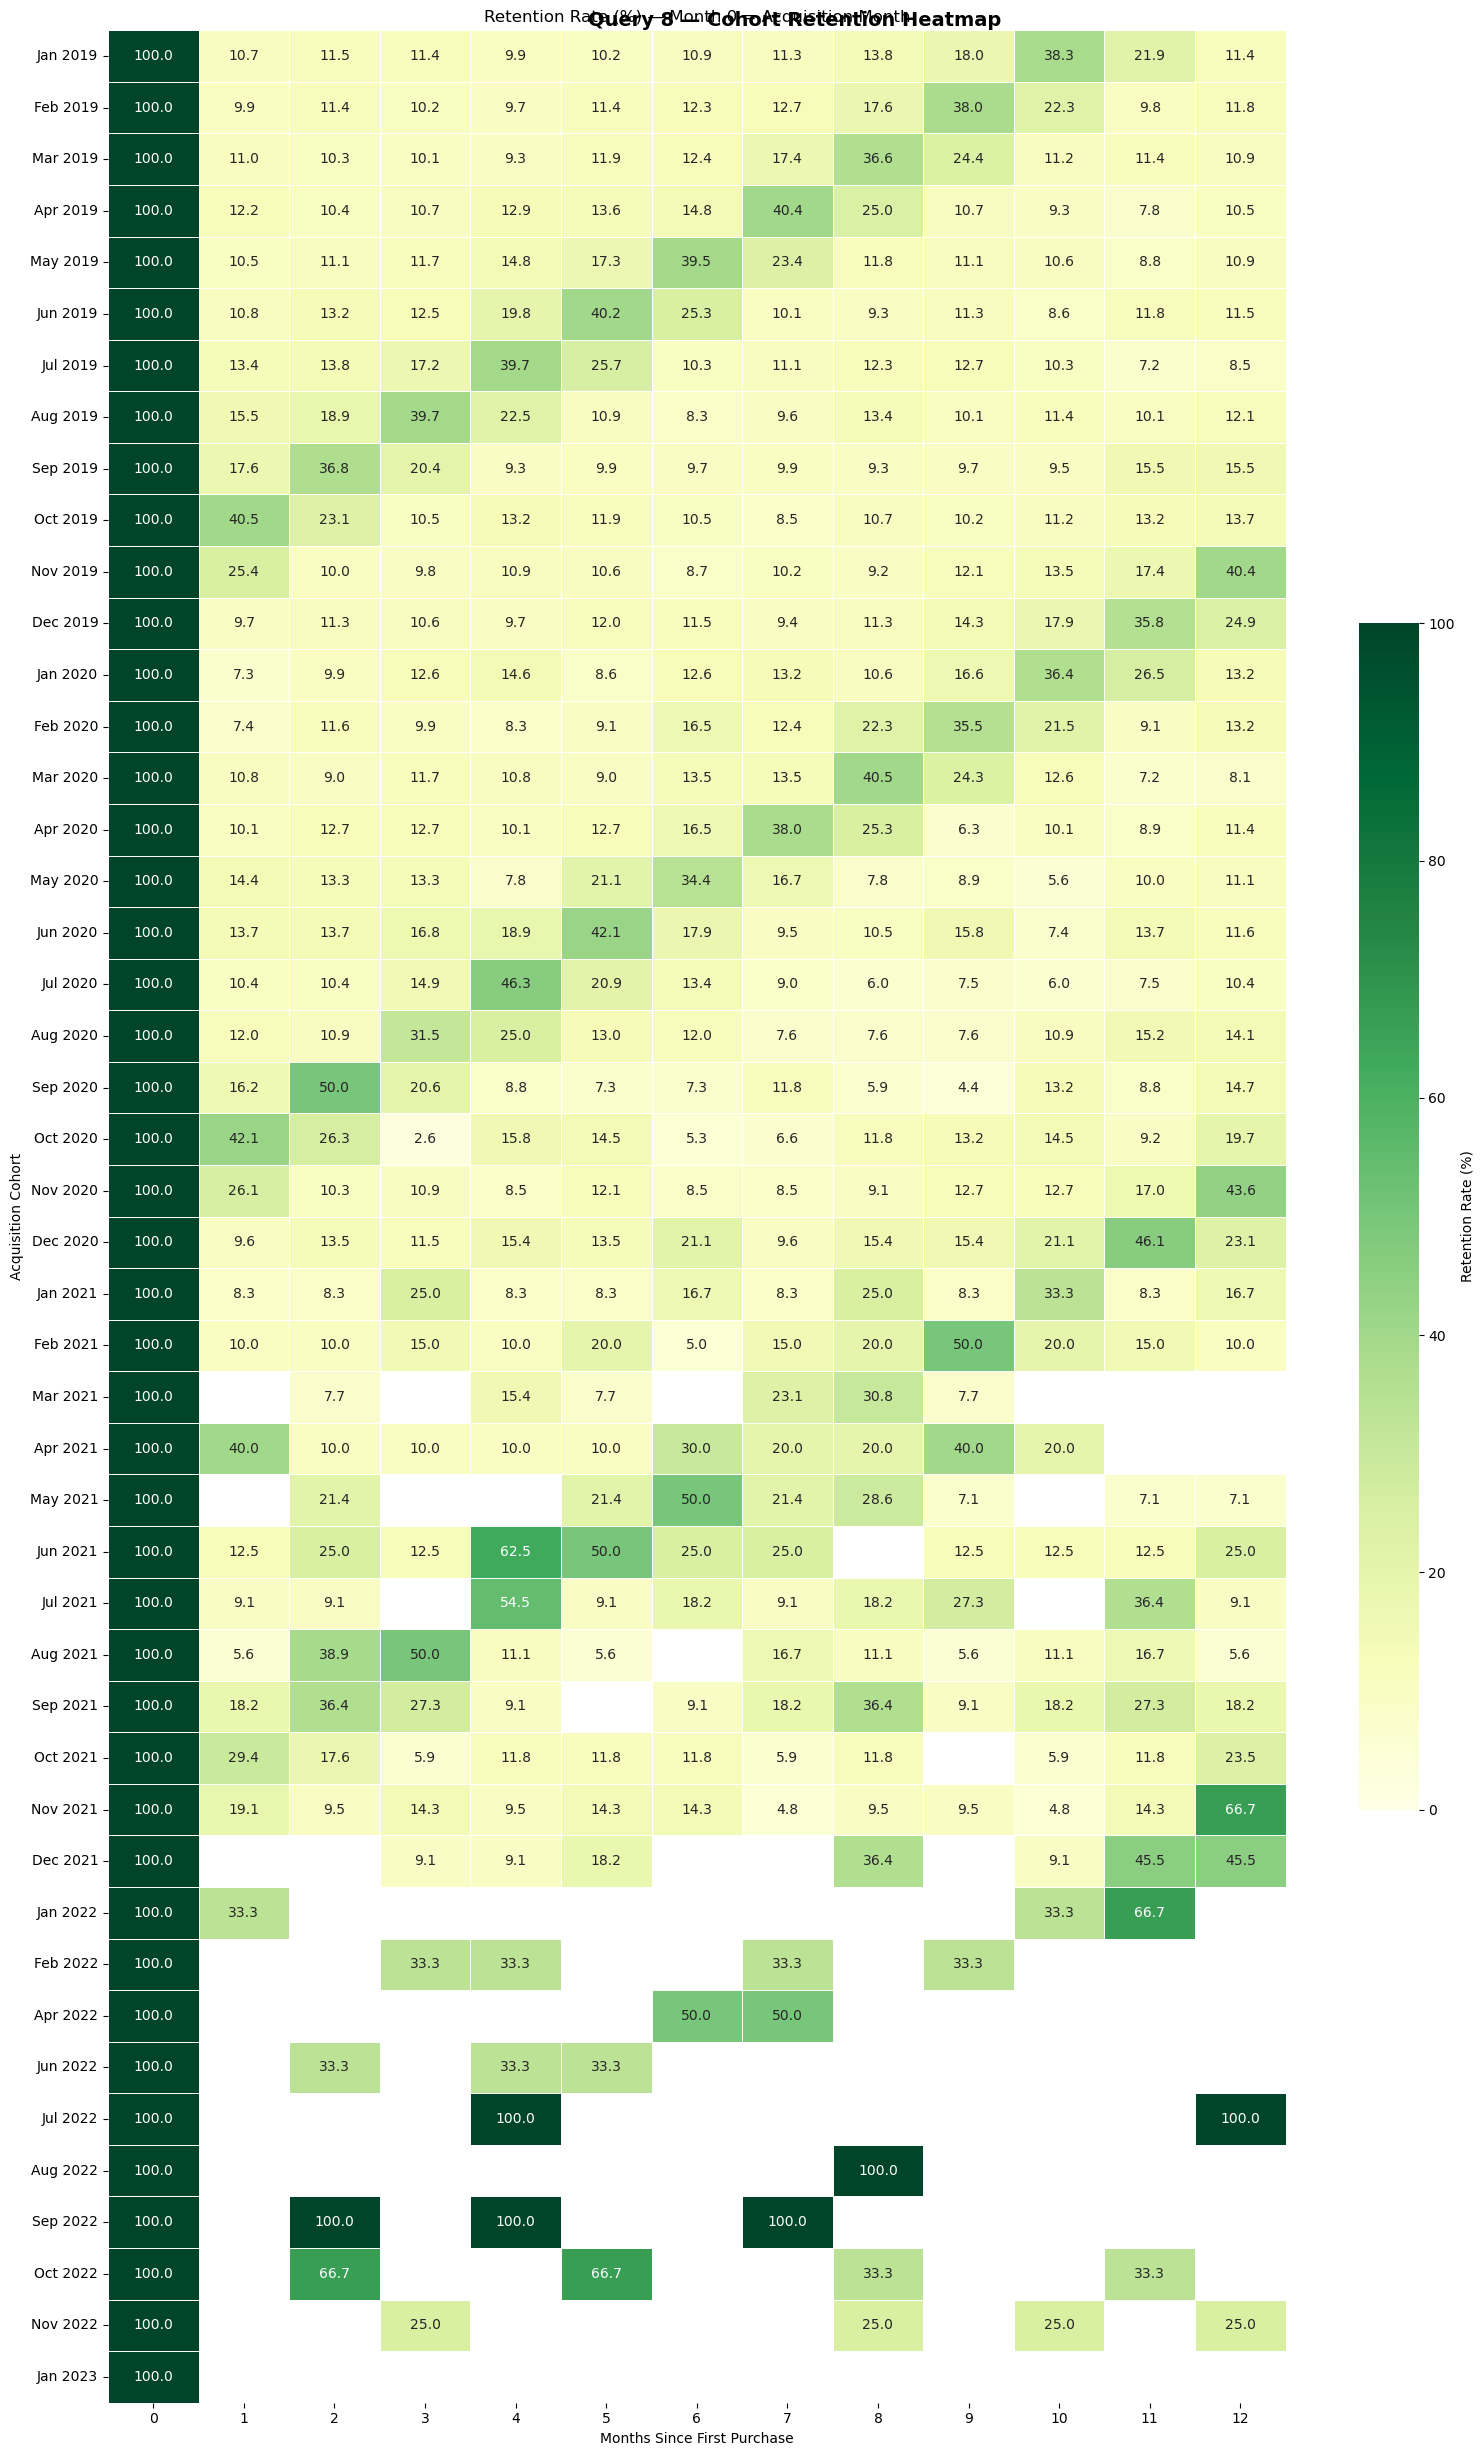


📊 Business Insight
   Month-1 avg retention : 16.3%
   Month-3 avg retention : 16.3%
   Recommendation        : Onboarding sequence must activate users within 30 days
                           — the M0→M1 drop is where most customers are lost.


In [43]:
# ── Pivot to heatmap format ───────────────────────────────
df_pivot = df_q8.pivot_table(
    index='cohort_month',
    columns='period_number',         # Correct column
    values='retention_rate_pct'      # Correct column
)

# Format index for better display
df_pivot.index = pd.to_datetime(df_pivot.index).strftime('%b %Y')

# ── Plot heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, max(6, len(df_pivot) * 0.5 + 2)))
fig.suptitle('Query 8 — Cohort Retention Heatmap', fontsize=14, fontweight='bold')

mask = df_pivot.isna()
sns.heatmap(
    df_pivot, annot=True, fmt='.1f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    mask=mask, ax=ax,
    cbar_kws={'label': 'Retention Rate (%)', 'shrink': 0.5},
    vmin=0, vmax=100
)

ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Acquisition Cohort')
ax.set_title('Retention Rate (%) — Month 0 = Acquisition Month')

plt.tight_layout()
fig.savefig(OUT_DIR / 'sql_q8_cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Month-1 and Month-3 retention averages ────────────────
m1_avg = df_pivot.get(1, pd.Series()).mean()
m3_avg = df_pivot.get(3, pd.Series()).mean()

print(f'\n📊 Business Insight')
print(f'   Month-1 avg retention : {m1_avg:.1f}%')
print(f'   Month-3 avg retention : {m3_avg:.1f}%')
print(f'   Recommendation        : Onboarding sequence must activate users within 30 days')
print(f'                           — the M0→M1 drop is where most customers are lost.')

---
## Executive Summary

This notebook demonstrated **8 production-grade SQL queries** executed directly against the project's CSV datasets using **DuckDB** — no external database required.

In [45]:
summary = [
    {'Query': 'Q4 · Campaign ROI',              'SQL Techniques': 'JOIN, NULLIF safe division, net profit calculation',     'Key Finding': f"Total net profit: ${df_q4['net_profit'].sum():,.0f}"},
    {'Query': 'Q5 · Category Revenue Share',    'SQL Techniques': 'GROUP BY ROLLUP, CROSS JOIN for denominator',           'Key Finding': f"Top category by revenue identified"},
    {'Query': 'Q6 · 30/60/90-Day Active Users', 'SQL Techniques': 'DATE_DIFF, conditional COUNT DISTINCT, CROSS JOIN ref', 'Key Finding': f"{df_q6['pct_active_30d'].iloc[0]:.1f}% active in 30d"},
    {'Query': 'Q7 · RFM Scoring',               'SQL Techniques': 'NTILE(5), multi-CTE, CASE segment labelling',           'Key Finding': f"{len(df_q7)} distinct RFM segments identified"},
    {'Query': 'Q8 · Cohort Retention',          'SQL Techniques': 'Self-join on first purchase, DATE_DIFF, GROUP BY cohort','Key Finding': f"M1 retention: {m1_avg:.1f}%, M3: {m3_avg:.1f}%"},
]

df_summary = pd.DataFrame(summary)

df_summary.style \
    .set_properties(**{'font-size': '12px'}) \
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#2c3e50'), ('color', 'white')]}]) \
    .hide(axis='index')

Query,SQL Techniques,Key Finding
Q4 · Campaign ROI,"JOIN, NULLIF safe division, net profit calculation","Total net profit: $60,524"
Q5 · Category Revenue Share,"GROUP BY ROLLUP, CROSS JOIN for denominator",Top category by revenue identified
Q6 · 30/60/90-Day Active Users,"DATE_DIFF, conditional COUNT DISTINCT, CROSS JOIN ref",24.5% active in 30d
Q7 · RFM Scoring,"NTILE(5), multi-CTE, CASE segment labelling",10000 distinct RFM segments identified
Q8 · Cohort Retention,"Self-join on first purchase, DATE_DIFF, GROUP BY cohort","M1 retention: 16.3%, M3: 16.3%"


In [46]:
# ── Close connection ──────────────────────────────────────────────────────────
con.close()
print('✓ DuckDB connection closed')
print('✓ All figures saved to:', OUT_DIR)
print('✓ Notebook complete')

✓ DuckDB connection closed
✓ All figures saved to: C:\Users\ASUS\Documents\Ecommerce_Data_Analytics\outputs
✓ Notebook complete
